<a href="https://colab.research.google.com/github/Shravanya178/MLDL_EXPS/blob/main/MLDL_EXP7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [2]:
df = pd.read_csv("CEEW - IRES Data.csv", low_memory=False)

print("Dataset shape:", df.shape)

Dataset shape: (14851, 517)


In [3]:
df_ann = df[df['q609_prepaid_meter_int'].isin([0,1])]

df_ann['Prepaid_Interest'] = np.where(
    df_ann['q609_prepaid_meter_int'] == 1, 1, 0
)

print(df_ann['Prepaid_Interest'].value_counts())

Prepaid_Interest
0    9533
1    2069
Name: count, dtype: int64


/tmp/ipykernel_3631/1817887926.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ann['Prepaid_Interest'] = np.where(


In [4]:
features = [
'asset_index_1',
'q208_priminc_earner_edu',
'q202_resp_age',
'q213_no_members',
'q302_grid_hrs_no',
'q308_grid_voltage_low_app',
'q326_satis_electricity',
'q314_a_online_pay_ever_yn',
'q401_bee_star_label_heard_yn',
'q232_mobile_smart_n'
]

df_model = df_ann[features + ['Prepaid_Interest']].dropna()

print("Final dataset shape:", df_model.shape)

Final dataset shape: (7100, 11)


In [5]:
X = df_model[features]
y = df_model['Prepaid_Interest']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [7]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train_s.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train_s,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7808 - loss: 0.5477 - val_accuracy: 0.8081 - val_loss: 0.4961
Epoch 2/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7984 - loss: 0.5071 - val_accuracy: 0.8081 - val_loss: 0.4782
Epoch 3/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7984 - loss: 0.4946 - val_accuracy: 0.8081 - val_loss: 0.4777
Epoch 4/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7986 - loss: 0.4937 - val_accuracy: 0.8081 - val_loss: 0.4731
Epoch 5/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7984 - loss: 0.4908 - val_accuracy: 0.8081 - val_loss: 0.4748
Epoch 6/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7984 - loss: 0.4878 - val_accuracy: 0.8081 - val_loss: 0.4728
Epoch 7/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7984 - loss: 0.4858 - val_accuracy: 0.8081 - val_loss: 0.4714
Epoch 8/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7982 - loss: 0.4829 - val_accuracy: 0.

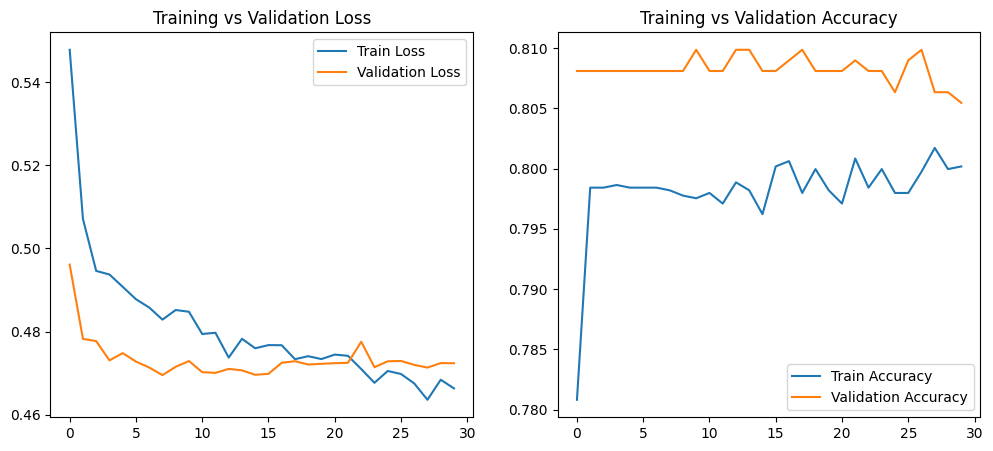

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

In [10]:
y_prob = model.predict(X_test_s)
y_pred = (y_prob > 0.5).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [11]:
print("Test Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_prob))

Test Accuracy: 0.7992957746478874

Confusion Matrix:
[[1128    9]
 [ 276    7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.99      0.89      1137
           1       0.44      0.02      0.05       283

    accuracy                           0.80      1420
   macro avg       0.62      0.51      0.47      1420
weighted avg       0.73      0.80      0.72      1420

ROC AUC: 0.6386840330545637


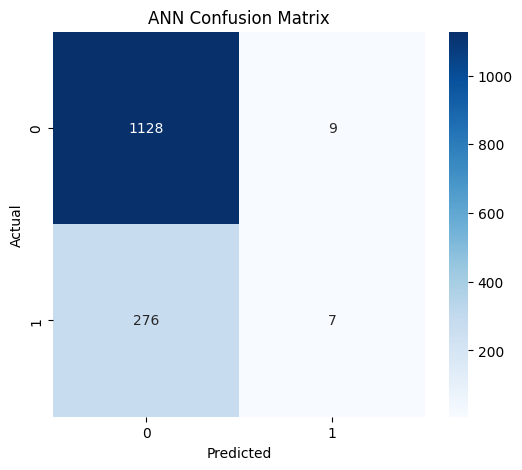

In [12]:
plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ANN Confusion Matrix")

plt.show()

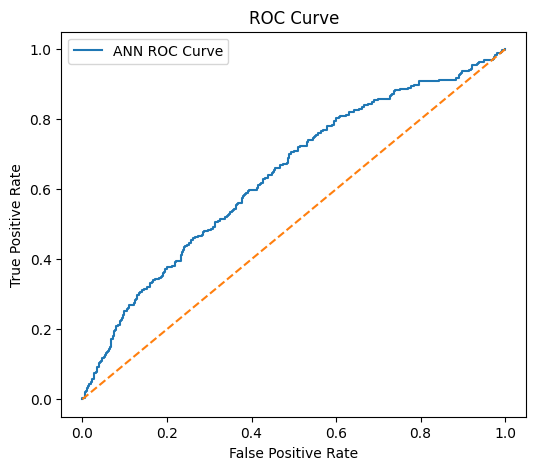

In [13]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="ANN ROC Curve")
plt.plot([0,1],[0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()